# Quantum Phase Estimation (QPE)

## Goal

Estimate the phase φ in:

U|ψ⟩ = exp(2πiφ)|ψ⟩

where:

- U is a unitary operator
- |ψ⟩ is an eigenvector

---

## Applications

- Order Finding
- Shor's Algorithm
- Quantum Chemistry
- Eigenvalue Estimation

---

## Visualizations

- Circuit Diagrams
- Statevectors
- Bloch Spheres
- State City Plots
- Histograms
- Binary Phase Recovery
- QFT Verification

---

Author: Muhammad Saad

In [1]:
!pip install qiskit qiskit-aer matplotlib pylatexenc ipywidgets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 102.8 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=40eed45b994c0fec9f35a9d74bfe6e0871646164e713900cd95278c1773e42fc
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [35]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import QFT

from qiskit.visualization import (
    plot_histogram,
    plot_state_city,
    plot_bloch_multivector
)

from qiskit_aer import AerSimulator

from IPython.display import display
import ipywidgets as widgets

In [36]:
phase_dropdown = widgets.Dropdown(
    options=[
        ("0.00",0.00),
        ("0.25",0.25),
        ("0.50",0.50),
        ("0.75",0.75)
    ],
    value=0.25,
    description="Phase:"
)

display(phase_dropdown)

Dropdown(description='Phase:', index=1, options=(('0.00', 0.0), ('0.25', 0.25), ('0.50', 0.5), ('0.75', 0.75))…

In [37]:
phi = phase_dropdown.value

print()
print("Chosen Phase:")
print(phi)


Chosen Phase:
0.25


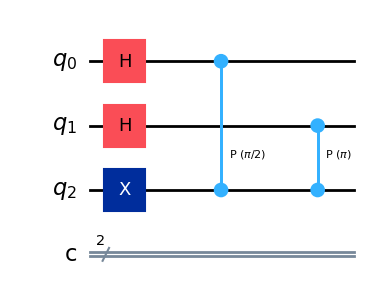

In [38]:
# Circuit Before IQFT

phi = phase_dropdown.value

qc = QuantumCircuit(3,2)

qc.x(2)

qc.h(0)
qc.h(1)

angle = 2*np.pi*phi

qc.cp(angle,0,2)
qc.cp(2*angle,1,2)

display(
    qc.draw("mpl")
)

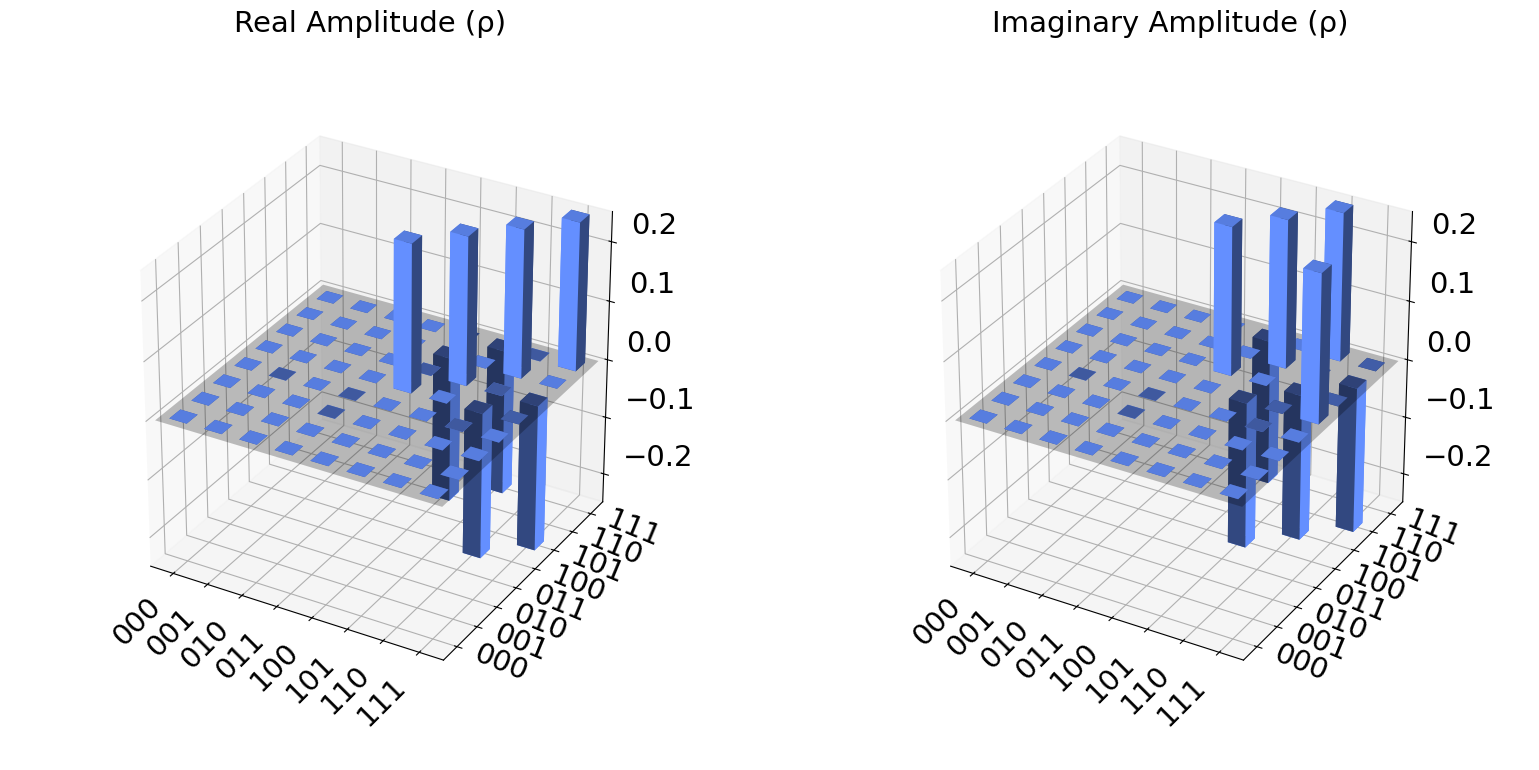

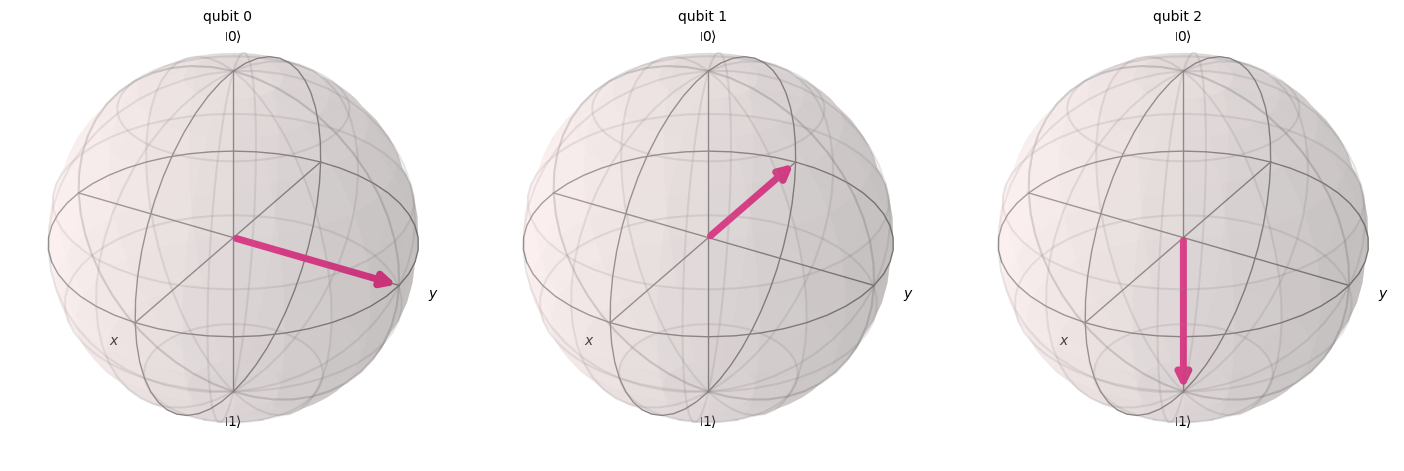

In [39]:
# State Before IQFT

state_before = Statevector.from_instruction(qc)

display(
    plot_state_city(state_before)
)

display(
    plot_bloch_multivector(state_before)
)

/tmp/ipykernel_1979/1216727289.py:1: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(


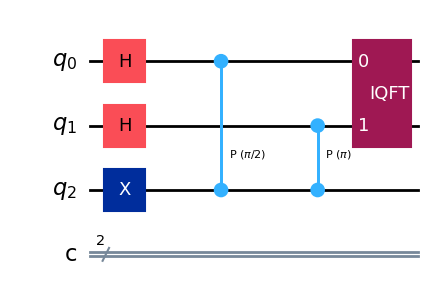

In [40]:
iqft = QFT(
    2,
    inverse=True
)

qc.compose(
    iqft,
    qubits=[0,1],
    inplace=True
)

display(
    qc.draw("mpl")
)

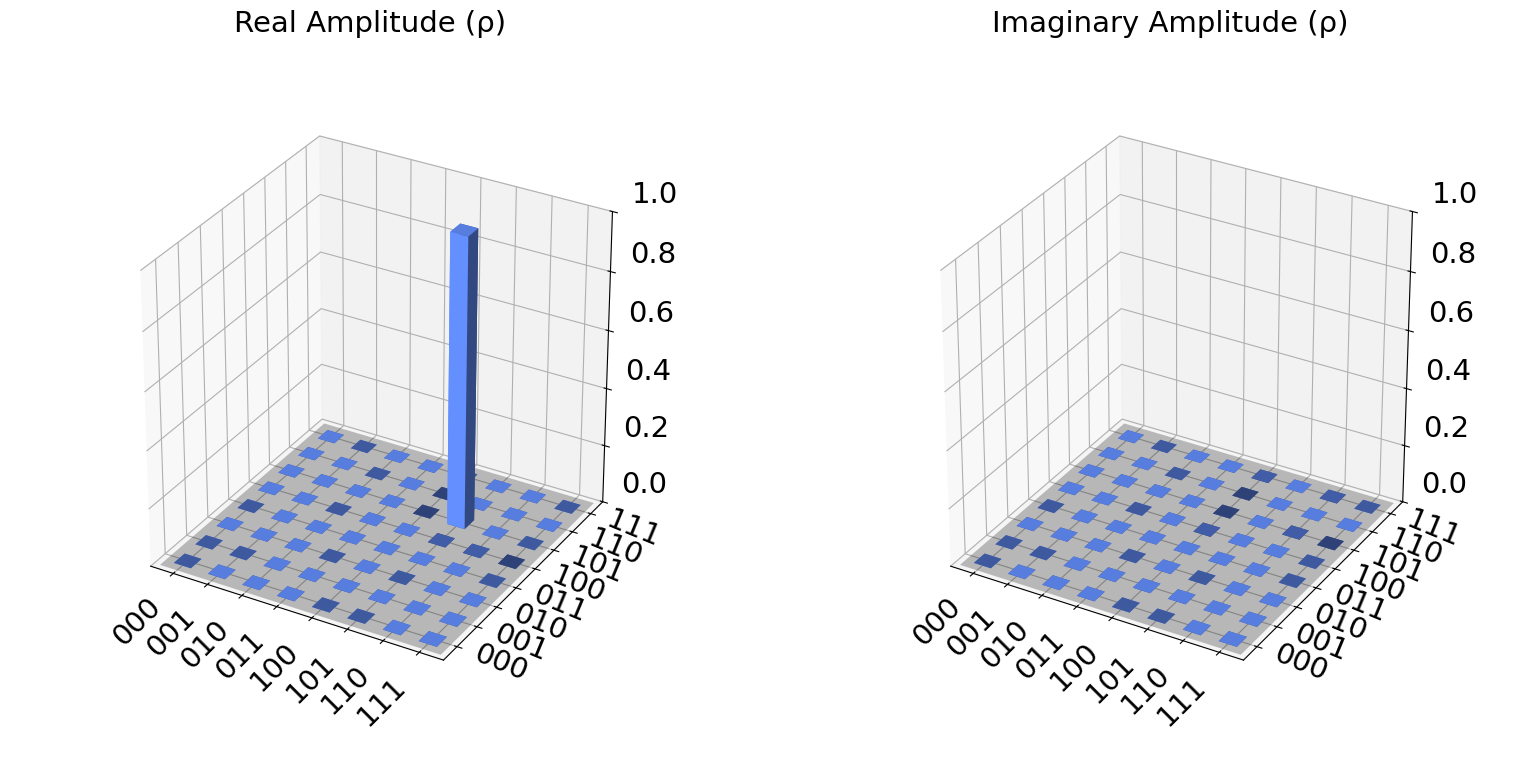

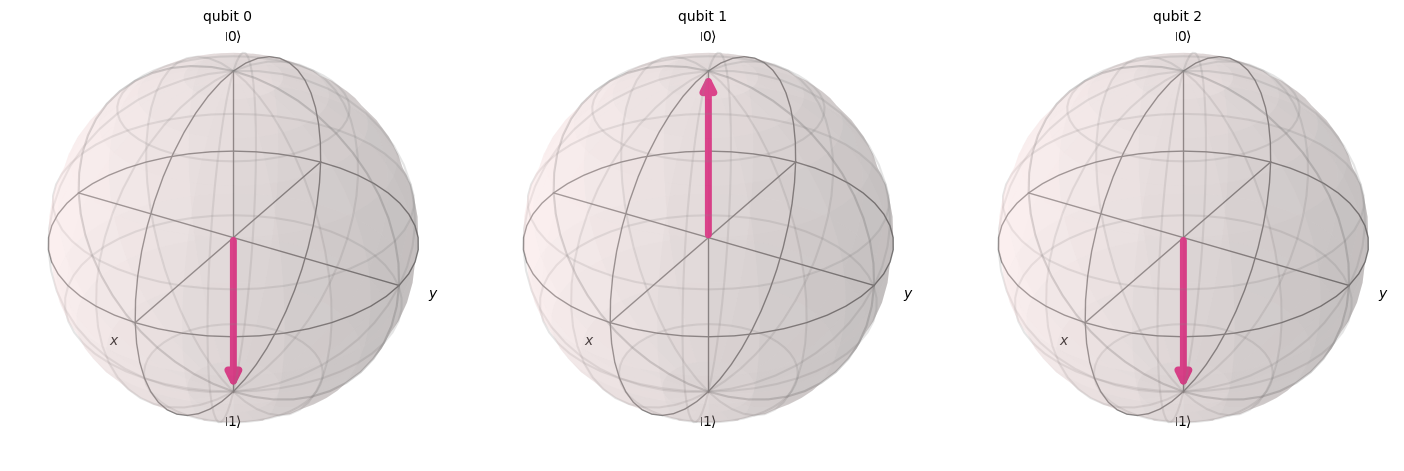

In [41]:
# State After IQFT

state_after = Statevector.from_instruction(qc)

display(
    plot_state_city(state_after)
)

display(
    plot_bloch_multivector(state_after)
)

In [42]:
# Measurement
qc.measure([0,1],[0,1])

In [43]:
# Execute

from qiskit import transpile

sim = AerSimulator()

compiled = transpile(
    qc,
    sim
)

result = sim.run(
    compiled,
    shots=1000
).result()

counts = result.get_counts()

print(counts)

{'01': 1000}


In [44]:
measured = max(counts,key=counts.get)

print("="*60)
print("PHASE ESTIMATION REPORT")
print("="*60)

print()

print("Actual Phase:")
print(phi)

print()

print("Measured Binary:")
print(measured)

PHASE ESTIMATION REPORT

Actual Phase:
0.25

Measured Binary:
01


In [46]:
# Binary to Decimal

phase_estimate = int(measured,2)/(2**2)

print()

print("Recovered Phase:")
print(phase_estimate)


Recovered Phase:
0.25


In [48]:
print("="*60)
print("MISSION REPORT")
print("="*60)

print()

print("A hidden phase existed.")

print()

print("Quantum computer encoded phase")

print()

print("Inverse QFT extracted phase")

print()

print("Recovered:")

print(phase_estimate)

print()

print("Mission Successful ✓")

MISSION REPORT

A hidden phase existed.

Quantum computer encoded phase

Inverse QFT extracted phase

Recovered:
0.25

Mission Successful ✓


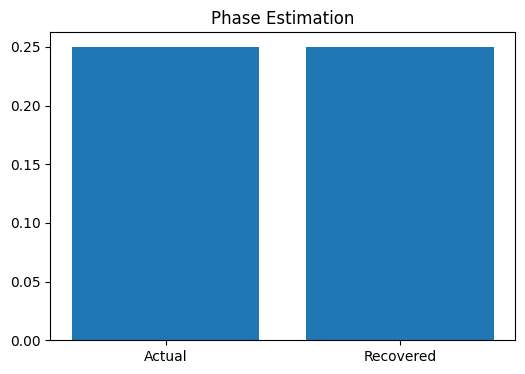

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    ["Actual","Recovered"],
    [phi,phase_estimate]
)

plt.title("Phase Estimation")

plt.show()

In [50]:
print("="*60)
print("WHY THIS MATTERS")
print("="*60)

print()

print("Order Finding uses Phase Estimation")

print("Shor uses Order Finding")

print("Therefore:")

print("QPE is the engine inside Shor.")

WHY THIS MATTERS

Order Finding uses Phase Estimation
Shor uses Order Finding
Therefore:
QPE is the engine inside Shor.
